# MARS DAS：单一主导模态 Scholte 波三台干涉去噪

## 1. 案例目标

分布式声学传感（distributed acoustic sensing，DAS）可以把海底通信光缆转化为超密集地震观测阵列。结合背景噪声互相关，DAS 可用于提取沿水体-沉积物界面传播的 Scholte 波。传统基于DAS的高频面波成像方法普遍采用子阵列叠加方法提取频散，子阵列叠加可提高频散能量的稳定性，但其结果代表子阵列范围内的平均响应，可能平滑小尺度横向结构。

TSI 直接作用于通道对尺度，TSI 增强满足一维直达面波几何走时关系的相干成分，并削弱不满足该关系的背景噪声及其他波场成分，有机会在增强直达 Scholte 波的同时保留 DAS 的密集空间采样。

本教程的学习线路是：先读取并预处理 ANC，再用 MASW 判断目标频散能量，随后对代表性通道对进行 TSI 诊断，最后运行全波场迭代去噪。每一步都先检查输入和波场条件，再进入下一步。

## 2. 研究区与数据

<div align="center" style="width: 60%; margin: 0 auto;">

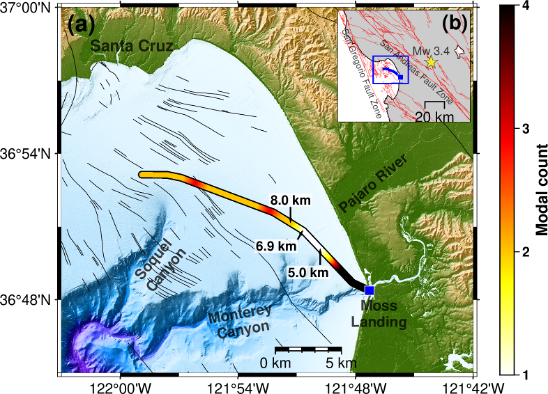

</div>

**Figure 1. Configuration of the MARS DAS array.** (a) MARS DAS阵列显示为一条粗曲线带，颜色代表各位置处的Scholte波模态总数（插值后）。图中还标示了已测绘的断层（黑线）和主要海底地形特征。黑色箭头标出了用于去噪和成像分析的两个区段的边界。(b) 区域地图显示了MARS wwDAS阵列（粗蓝线），蓝色矩形框标示了(a)图中放大的区域。已测绘的断层和DAS记录期间发生的Mw 3.4级吉尔罗伊（Gilroy）地震分别以红线和黄色星号标示。（修改自 Yuan et al., 2026）

Monterey Accelerated Research System（MARS）海底光缆位于美国加利福尼亚州 Monterey Bay 大陆架。相关 DAS 观测具有以下特征：

- 背景噪声连续记录时间为 2018 年 3 月 10-13 日；
- 阵列总长度约 20 km；
- DAS 标距为 10 m；
- 原始通道间距约 2 m；
- ANC 以 20 m 通道间距计算；

MARS DAS 记录为沿光缆方向的单分量应变或应变率响应，无法利用径向-垂向质点运动进行极化分离，同时该 DAS 阵列上的面波模态变化复杂，难以可靠给定模式标签，因此，本教程不尝试在全光缆范围内分离多模态 Scholte 波，而是选取一段单模态 Scholte 波主导区段（5-6.9 km; 通道250-345，在本教程选定的 5.0–6.9 km 区段及分析频带内，MASW 主能量带被解释为第一高阶 Scholte 波）开展去噪作为演示。

### 数据来源与推荐引用

本教程所用 MARS DAS 示例数据去噪的研究背景、Figure 1 和 Scholte 波模态解释详见以下在审稿件：

> Yuan, Y., Qiu, H., Chi, B., & Qin, L. (2026).  
> *Mitigating the Resolution–SNR Trade-Off in DAS Ambient Noise Imaging: Application to Monterey Bay*.  
> Manuscript under review at *Journal of Geophysical Research: Solid Earth*.

这里的 `input_public/` 是为教学准备的均匀抽样输入（均匀保留 48 个通道及其全部 1,128 个通道对）；台站名保持原始命名。缓存写入本案例目录下的 `processed/`，因此重复运行时可以跳过耗时的读取、MASW 和去噪计算。

## 3. Step 0：导入程序并设置参数
本步骤只负责准备路径、导入接口和固定参数。距离单位为 km，时间单位为 s，频率单位为 Hz，相速度单位为 km/s；后续图和文本摘要沿用这些单位。

In [1]:

from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

from tsi_denoising import (
    Wavefield,
    MASW,
    DenoisingResult,
    read_sac_directory,
    denoise_station_pair_demo,
    denoise_wavefield_iteratively,
    plot_denoised_result,
)

COMPONENTS = ("RR",)  # 本案例只有一个径向-径向 ANC 分量。
FMIN = 0.5; FMAX = 3.5  # MASW 和后续分析的频率范围，单位 Hz。
VMIN = 0.1; VMAX = 2.0  # 速度窗边界，单位 km/s。
EXAMPLE_PAIR = ("270", "325")  # 用于诊断和迭代去噪的代表性台站对。
EXAMPLE_PERIODS = (1.6, 0.4)  # 诊断图的中心周期，单位 s。

## 4. Step 1：读取、缓存与预处理波场
`read_sac_directory()` 将一个分量目录中的 SAC 互相关组织为 `Wavefield`。`preprocess()` 对每个台站对执行正负时间对称化、速度窗 taper 和零相位带通滤波。若 NPZ 缓存存在，本步骤直接加载它；因此要改变预处理参数时，应删除对应缓存后重新运行。

In [2]:
project_root = next(
    candidate
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (candidate / "tutorial" / "_paths.py").is_file()
)
sys.path.insert(0, str(project_root / "tutorial"))
from _paths import resolve_case_paths
CASE_DIR, SAC_DIR, PROCESSED_DIR = resolve_case_paths(
    "MARS_DAS",
    cwd=Path.cwd(),
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

if not SAC_DIR.is_dir():
    raise FileNotFoundError(
        f"输入数据目录不存在：{SAC_DIR.resolve()}\n"
        "请先运行 `python retrieve_datasets.py` 下载教学数据。"
    )

print(f"输入数据目录：{SAC_DIR}")
print(f"缓存目录：{PROCESSED_DIR}")


print(f"参数：component={COMPONENTS[0]}, frequency={FMIN}-{FMAX} Hz, velocity={VMIN}-{VMAX} km/s")

输入数据目录：/Users/yusong/projects/TSI-Denoising/tutorial/MARS_DAS/input_public
缓存目录：/Users/yusong/projects/TSI-Denoising/tutorial/MARS_DAS/processed
参数：component=RR, frequency=0.5-3.5 Hz, velocity=0.1-2.0 km/s


[MARS DAS / RR] cache hit; pairs=1128, stations=48 (250-345), samples=2501
  sampling: delta=0.040000 s, rate=25.000 Hz; time=-50.000..50.000 s
  distances: 0.0400..1.9000 km


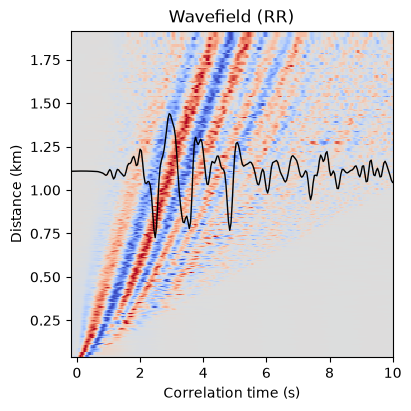

In [3]:
component = COMPONENTS[0]
cache_path = PROCESSED_DIR / f"{component.lower()}_wavefield.npz"
cache_hit = cache_path.exists()
if cache_hit:
    # 已有缓存时直接恢复预处理后的 Wavefield，避免重复读取 SAC。
    wfd_rr = Wavefield.load(cache_path)
else:
    # 首次运行：读取 SAC，并应用上面声明的频带和速度窗。
    wfd_rr = read_sac_directory(SAC_DIR / component).preprocess(
        fmin=FMIN,
        fmax=FMAX,
        vmin=VMIN,
        vmax=VMAX,
    )
    wfd_rr.save(cache_path, overwrite=True)
wfd_rr.print(
    "MARS DAS / RR",
    status="cache hit" if cache_hit else "read and preprocessed",
)


fig, ax = plt.subplots(
    1, 1,
    figsize=(4, 4.),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

wfd_rr.plot(ax=ax, example_pair=EXAMPLE_PAIR, jitter_duplicate_distances=True,tshow_min=-0.2, tshow_max=10.0)
plt.show()


## 5. Step 2：MASW 检查主导 Scholte 波

### 进入 TSI 前的判断

只有当目标波在所选子阵列内具有稳定单一主导模态时，才进入三台干涉去噪。

MASW 图中的横轴是频率，纵轴是相速度，颜色表示归一化叠加能量。 

连续能量带是进入 TSI 的必要质量控制，但不能独立证明模态阶次。

[MARS DAS / RR MASW] grid=(1500, 141); frequency=0.502..3.499 Hz; velocity=0.100..1.500 km/s
  strongest normalized energy: f=0.502 Hz, v=0.940 km/s


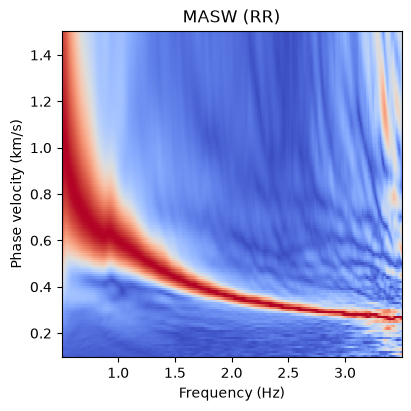

In [4]:
component = COMPONENTS[0]
cache_path = PROCESSED_DIR / f"{component.lower()}_masw.npz"
masw_cache_hit = cache_path.exists()
if masw_cache_hit:
    # MASW 缓存包含频率-相速度能量图，可直接用于质量检查。
    masw_rr = MASW.load(cache_path)
else:
    # 速度网格决定图像的纵向采样；n_jobs 只影响计算并行度。
    masw_velocity_grid = np.linspace(0.1, 1.5, 141)
    masw_rr = MASW(
        wfd_rr,
        fmin=FMIN,
        fmax=FMAX,
        velocities=masw_velocity_grid,
    ).compute(n_jobs=10)
    masw_rr.save(cache_path, overwrite=True)
masw_rr.print("MARS DAS / RR MASW")

fig, ax = plt.subplots(
    1, 1,
    figsize=(4, 4.),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

masw_rr.plot(ax=ax)
plt.show()

## 6. Step 3：代表性通道对的 TSI 诊断
诊断图按周期展示输入波场、目标台站的虚拟炮集、三台干涉结果。

诊断台站对：270-325, distance=1.1000 km; periods=(1.6, 0.4) s


(<Figure size 1000x850 with 8 Axes>,
 array([[<Axes: title={'center': 'Virtual shot gather at station 270'}, ylabel='Station number'>,
         <Axes: title={'center': 'Virtual shot gather at station 325'}>,
         <Axes: title={'center': 'Three-station interferometry'}>],
        [<Axes: xlabel='Correlation time (s)', ylabel='Station number'>,
         <Axes: xlabel='Correlation time (s)'>,
         <Axes: xlabel='Correlation time (s)'>]], dtype=object))

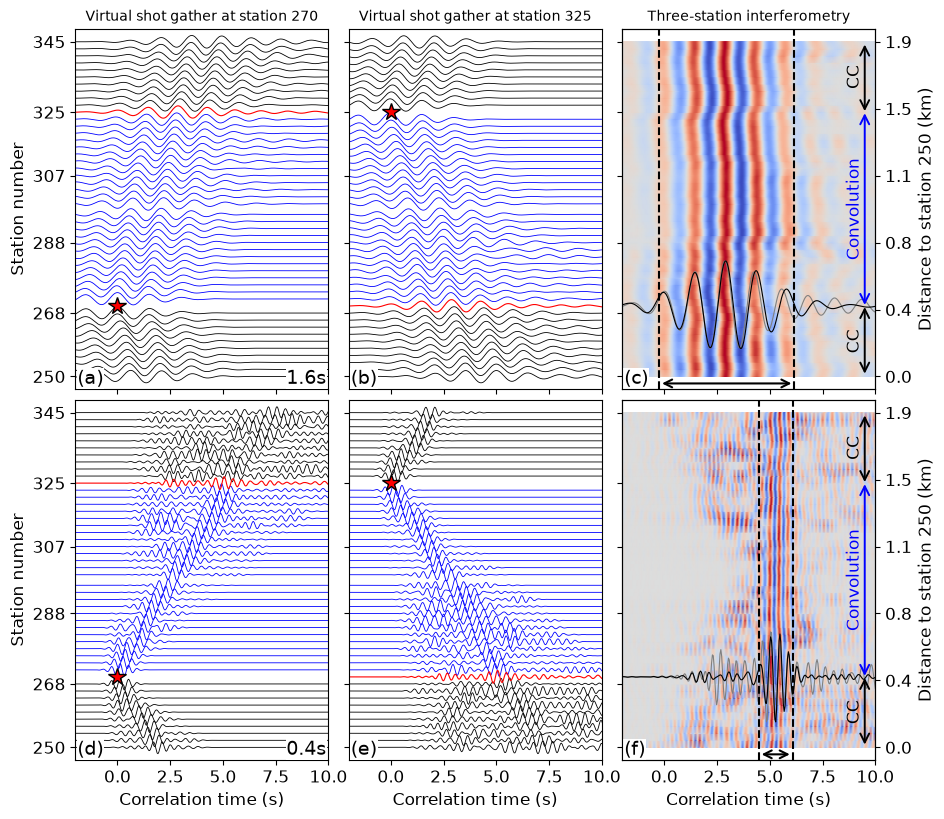

In [5]:
pair_index = wfd_rr.pairs.index(EXAMPLE_PAIR)
pair_distance = wfd_rr.distances[pair_index]
print(
    f"诊断台站对：{EXAMPLE_PAIR[0]}-{EXAMPLE_PAIR[1]}, distance={pair_distance:.4f} km; "
    f"periods={EXAMPLE_PERIODS} s"
)
# 该图是局部质量控制，不会修改输入 Wavefield。
denoise_station_pair_demo(
    wfd_rr,
    EXAMPLE_PAIR,
    periods=EXAMPLE_PERIODS,
    time_limits=(-2, 10),
)

## 7. Step 4：全波场迭代去噪
该步骤对波场中的每个通道对分别构造满足几何条件的三台干涉候选，并进行迭代去噪；`EXAMPLE_PAIR` 用于记录和展示代表性迭代历史，并不决定其他通道对的结果。。`threshold` 控制相邻迭代的相对变化，`max_iterations` 设置安全上限；摘要中的 `converged` 和 `stop_reason` 用来判断本次运行是达到阈值停止，还是达到迭代上限停止。

Loaded cached denoising result.
[MARS DAS TSI] iterations=3, converged=True, stop_reason=threshold
  relative changes: [0.5887, 0.1433, 0.0423]
  files: Denoised_wavefield.npz, Denoised_info.npz


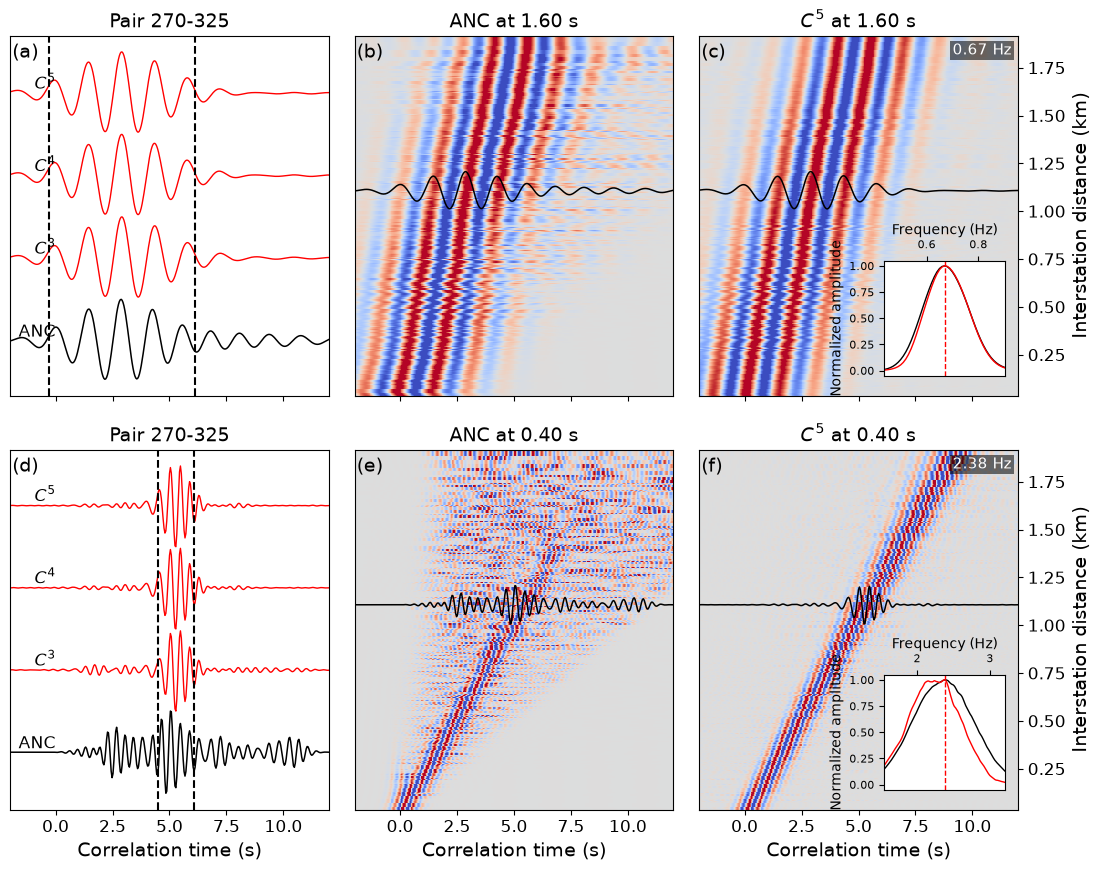

In [6]:
# DenoisingResult 会同时保存最终 Wavefield 和迭代诊断信息。
result_stem = PROCESSED_DIR / "Denoised"
wavefield_file = PROCESSED_DIR / "Denoised_wavefield.npz"
info_file = PROCESSED_DIR / "Denoised_info.npz"

if wavefield_file.exists() and info_file.exists():
    # 两个结果文件都存在才认为缓存完整，避免读取半成品。
    denoised_result = DenoisingResult.load(result_stem)
    print("Loaded cached denoising result.")
else:
    # threshold 是相邻迭代的相对变化阈值；max_iterations 是安全上限。
    denoised_result = denoise_wavefield_iteratively(
        wfd_rr,
        EXAMPLE_PAIR,
        threshold=0.05,
        first_iteration_convolution=True,
        max_iterations=6,
        taper_output=False,
        n_jobs=10,
    )
    denoised_result.save(
        result_stem,
        overwrite=wavefield_file.exists() or info_file.exists(),
    )
    print("Computed and saved denoising result.")
denoised_result.print("MARS DAS TSI")
print(f"  files: {wavefield_file.name}, {info_file.name}")

plot_denoised_result(wfd_rr, denoised_result, periods=EXAMPLE_PERIODS, time_limits=(-2, 12))
plt.show()

[Final wavefield] cache: /Users/yusong/projects/TSI-Denoising/tutorial/MARS_DAS/processed/Denoised_wavefield.npz; pairs=1128, stations=48 (250-345), samples=2501
  sampling: delta=0.040000 s, rate=25.000 Hz; time=-50.000..50.000 s
  distances: 0.0400..1.9000 km


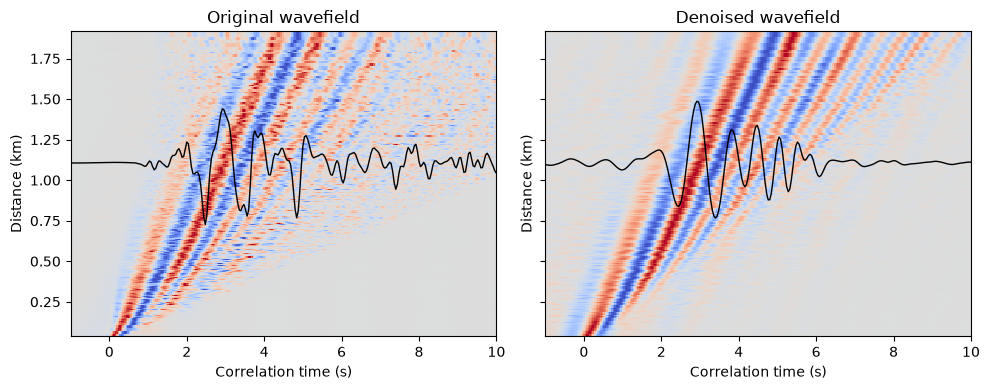

In [7]:
# 重新加载最终波场，直观比较去噪前后的空间-时间结构。
denoised_wavefield = Wavefield.load(PROCESSED_DIR / "Denoised_wavefield.npz")
denoised_wavefield.print(
    "Final wavefield",
    status=f"cache: {PROCESSED_DIR / 'Denoised_wavefield.npz'}",
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

wfd_rr.plot(
    ax=axes[0],
    example_pair=EXAMPLE_PAIR,
    tshow_max=10,
    tshow_min=-1,
    jitter_duplicate_distances=True,
)
axes[0].set_title("Original wavefield")

denoised_wavefield.plot(
    ax=axes[1],
    example_pair=EXAMPLE_PAIR,
    tshow_max=10,
    tshow_min=-1,
    jitter_duplicate_distances=True,
)
axes[1].set_title("Denoised wavefield")

plt.tight_layout()
plt.show()